In [4]:
suppressPackageStartupMessages(library(tidyverse))
library(here)

r_out <- here("reports", "figures")
model_path <- here("data", "models")

PLOT_WIDTH <- 9
PLOT_HEIGHT <- 6


In [2]:
read_model <- function(model_type, party, model_file) {
    fpath <- here(model_path, model_type, party, model_file)
    readRDS(fpath)
}

create_summary <- function(model, var) {
    model_summary <- summary(model)

    df <- model_summary$fixed |>
        rownames_to_column("term") |>
        filter(term == !!var) |>
        rename(est = Estimate, upper_ci = `u-95% CI`, lower_ci = `l-95% CI`, rhat = Rhat) |>
        select(lower_ci, est, upper_ci, rhat)

    return(df)
}

read_files <- function() {
    model_types <- list.dirs(model_path, recursive = FALSE, full.names = FALSE)

    dfs <- list()
    i <- 0
    for (model_type in model_types) {
        words <- stringr::word(model_type, 1:2, sep = "_")
        type <- words[1]
        var <- words[2]

        parties <- list.dirs(here(model_path, model_type), recursive = FALSE, full.names = FALSE)

        for (party in parties) {
            model_files <- list.files(here(model_path, model_type, party), recursive = FALSE, full.names = FALSE)

            for (model_file in model_files) {
                quantile <- str_extract(model_file, "\\d+") |> as.integer()
                model <- read_model(model_type, party, model_file)

                i <- i + 1
                sub_df <- create_summary(model, var) |>
                    mutate(
                        party = party,
                        quantile = quantile,
                        type = type,
                        var = var
                    )
                dfs[[i]] <- sub_df
            }
        }
    }

    bind_rows(dfs)
}


In [3]:
df <- read_files()


# Views Elite


[1] TRUE

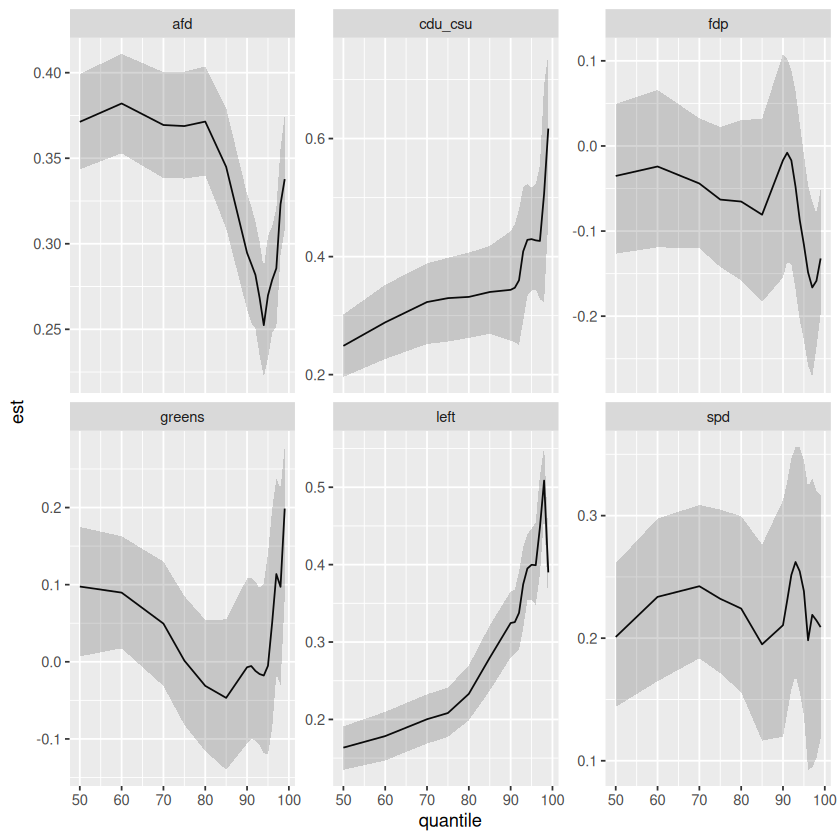

In [5]:
plot <- df |>
    filter(type == "views", var == "elite") |>
    ggplot(aes(x = quantile, y = est)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), alpha = 0.2) +
    facet_wrap(~party, scales = "free_y")

path <- here("reports", "figures", "reg_views_elite.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


# Likes Elite


[1] TRUE

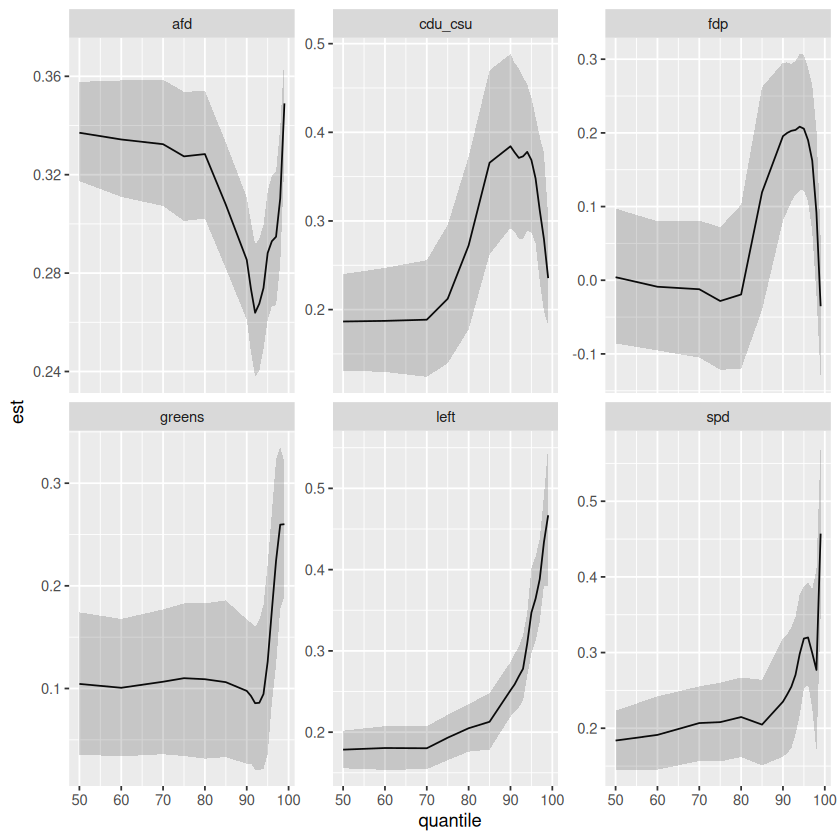

In [6]:
plot <- df |>
    filter(type == "likes", var == "elite") |>
    ggplot(aes(x = quantile, y = est)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), alpha = 0.2) +
    facet_wrap(~party, scales = "free_y")

path <- here("reports", "figures", "reg_likes_elite.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


# Views Pplcentr


[1] TRUE

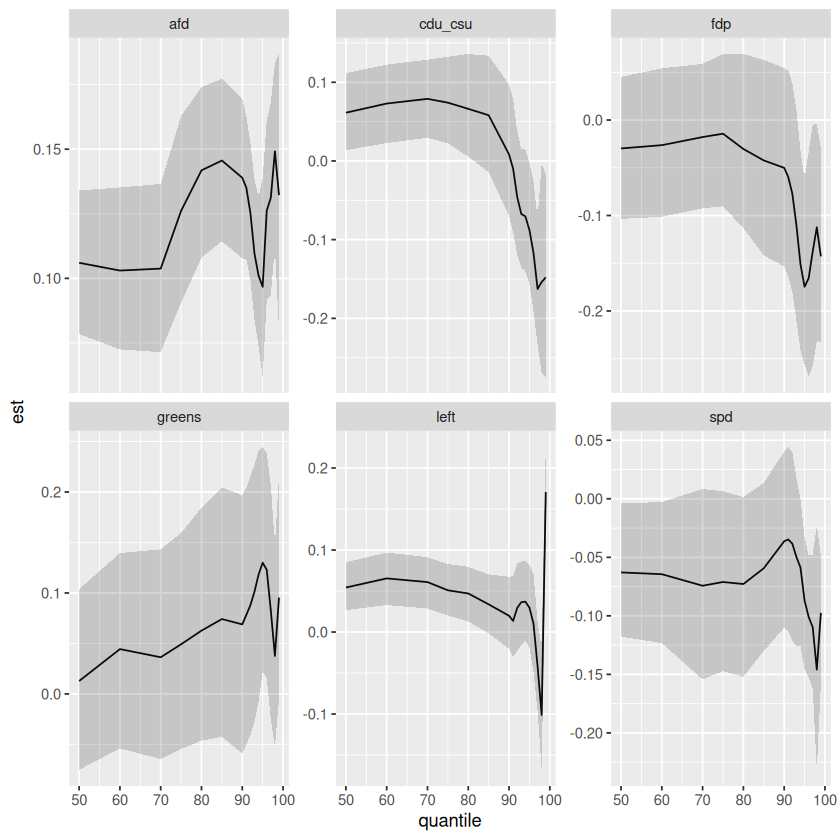

In [7]:
plot <- df |>
    filter(type == "views", var == "pplcentr") |>
    ggplot(aes(x = quantile, y = est)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), alpha = 0.2) +
    facet_wrap(~party, scales = "free_y")

path <- here("reports", "figures", "reg_views_pplcentr.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


# Likes Pplcentr


[1] TRUE

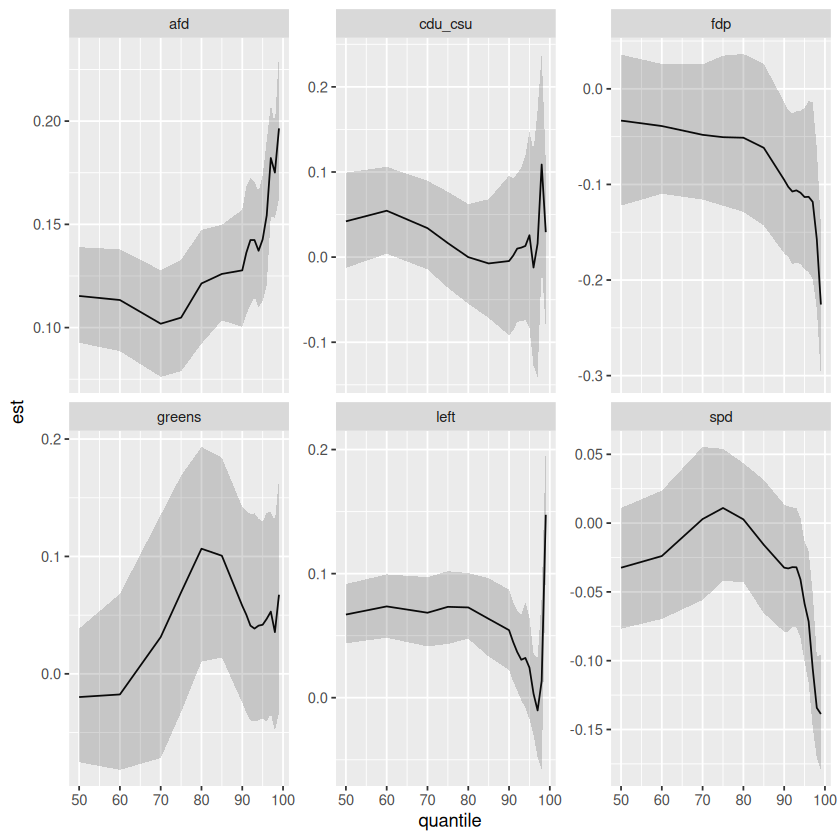

In [8]:
plot <- df |>
    filter(type == "likes", var == "pplcentr") |>
    ggplot(aes(x = quantile, y = est)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), alpha = 0.2) +
    facet_wrap(~party, scales = "free_y")

path <- here("reports", "figures", "reg_likes_pplcentr.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


In [9]:
min(df$rhat)
max(df$rhat)


[1] 0.9998679

[1] 1.002039